In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [11]:
csv_path = 'results/benchmark_results.csv'
if not os.path.exists(csv_path):
    print(f"Ошибка: Файл {csv_path} не найден. Сначала запустите C++ бенчмарк.")
else:
    df = pd.read_csv(csv_path)

In [12]:
# Настройка красивой палитры и стиля
custom_palette = {
    "Std QuickSort": "#34495e",
    "Std MergeSort": "#7f8c8d",
    "Custom QuickSort": "#2c3e50",
    "Custom MergeSort": "#95a5a6",
    "Ternary QuickSort": "#e74c3c",
    "String MergeSort": "#e67e22",
    "MSD Radix Sort": "#2ecc71",
    "MSD Radix Sort + Fallback": "#1abc9c"
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 20
})

In [13]:
def plot_dataset(array_type, use_log=False):
    subset = df[df['ArrayType'] == array_type]
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=100)
    fig.suptitle(f'Производительность на наборе данных: {array_type}', fontsize=20, fontweight='bold', color='#2c3e50', y=1.05)

    # График времени
    sns.lineplot(data=subset, x='Size', y='TimeMs', hue='Algorithm', palette=custom_palette, marker='o', markersize=6, linewidth=2.5, ax=axes[0])
    axes[0].set_title('Время выполнения от размера массива', pad=15)
    axes[0].set_xlabel('Размер массива (N)', labelpad=10)
    axes[0].set_ylabel('Среднее время (мс)', labelpad=10)
    axes[0].get_legend().remove()

    # График сравнений
    sns.lineplot(data=subset, x='Size', y='Comparisons', hue='Algorithm', palette=custom_palette, marker='s', markersize=6, linewidth=2.5, ax=axes[1])
    axes[1].set_title('Посимвольные сравнения от размера массива', pad=15)
    axes[1].set_xlabel('Размер массива (N)', labelpad=10)
    axes[1].set_ylabel('Среднее число сравнений', labelpad=10)
    
    if use_log:
        axes[1].set_yscale('log')
        axes[1].set_ylabel('Среднее число сравнений (Лог. шкала)', labelpad=10)
        
    axes[1].legend(title='Алгоритмы', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

### 1. Случайные строки (Random Arrays)

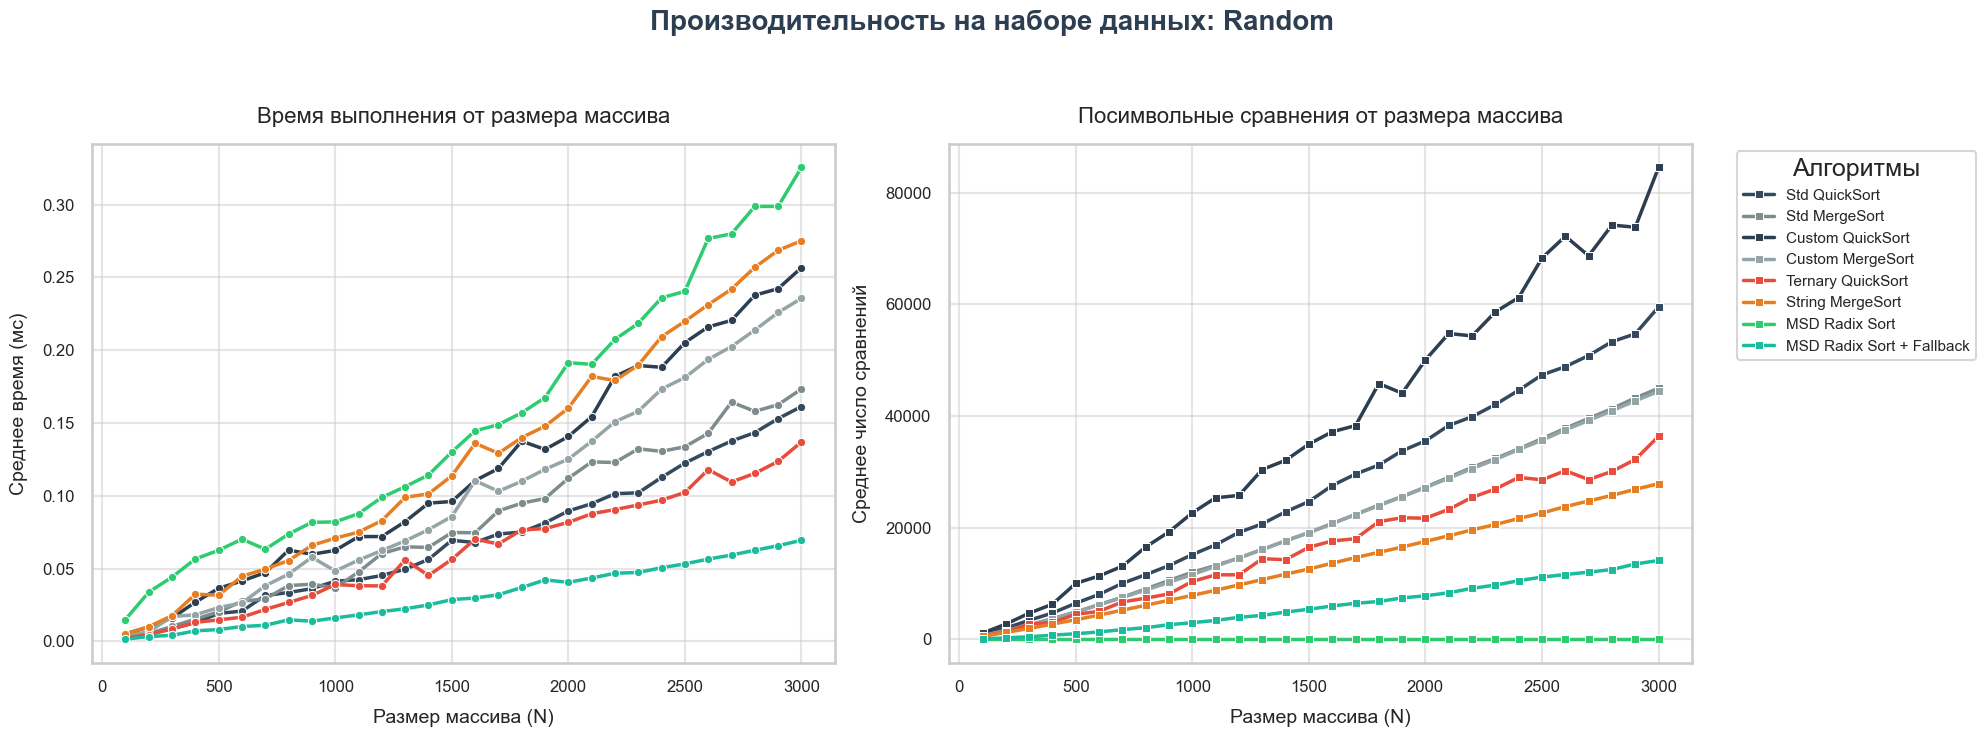

In [14]:
plot_dataset('Random')

### 2. Обратно упорядоченные строки (Reverse Sorted Arrays)

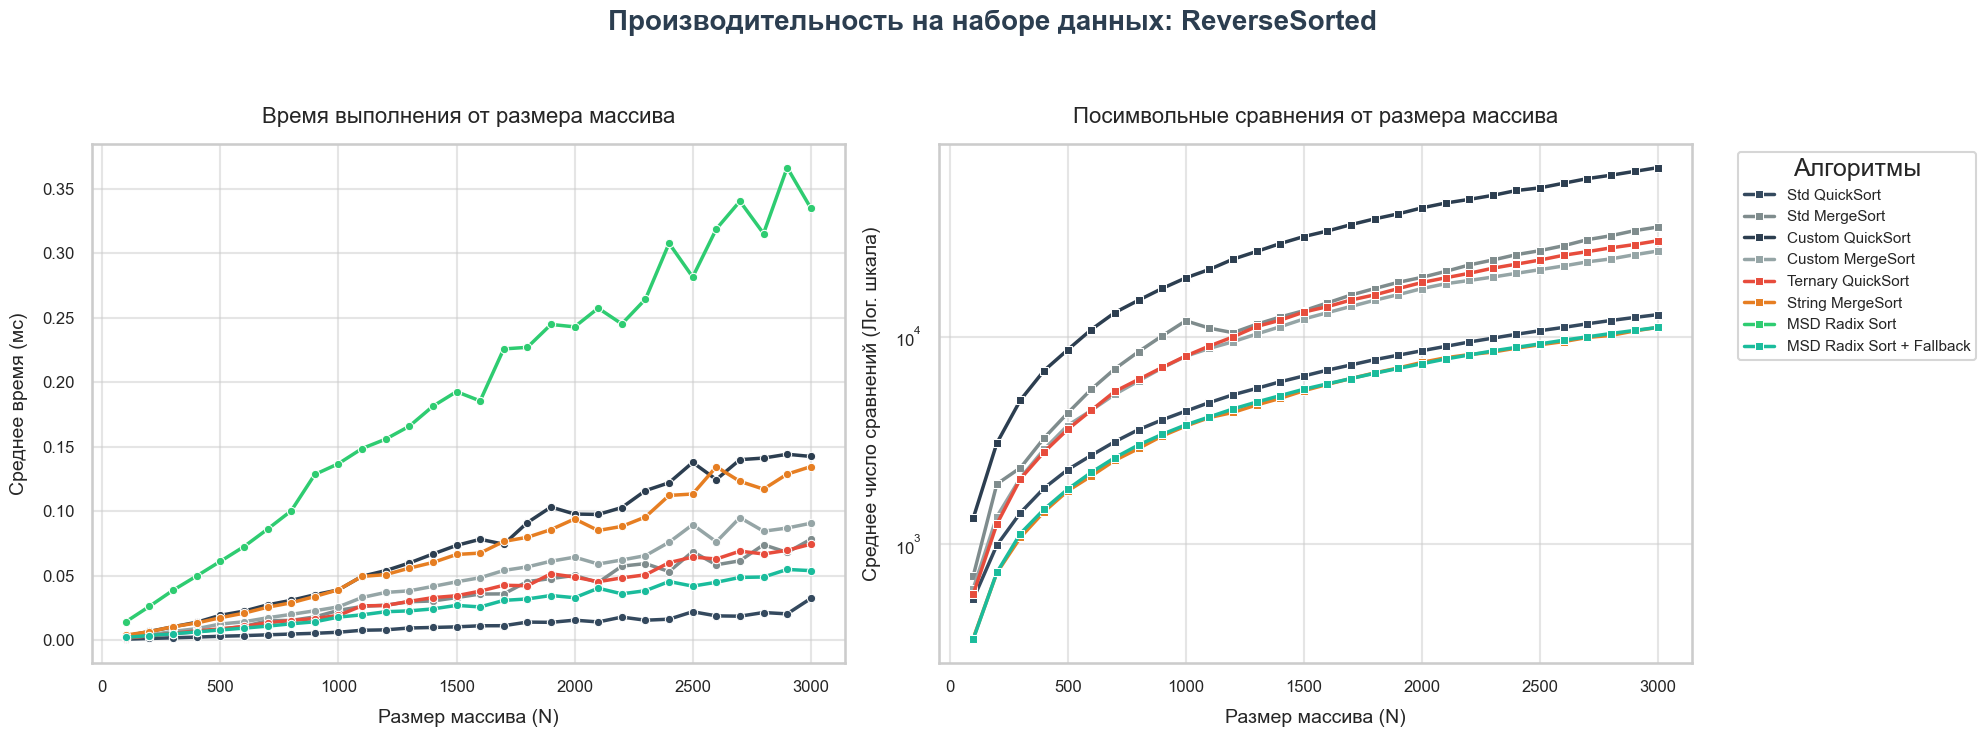

In [15]:
plot_dataset('ReverseSorted', use_log=True)

### 3. Почти отсортированные строки (Nearly Sorted Arrays)

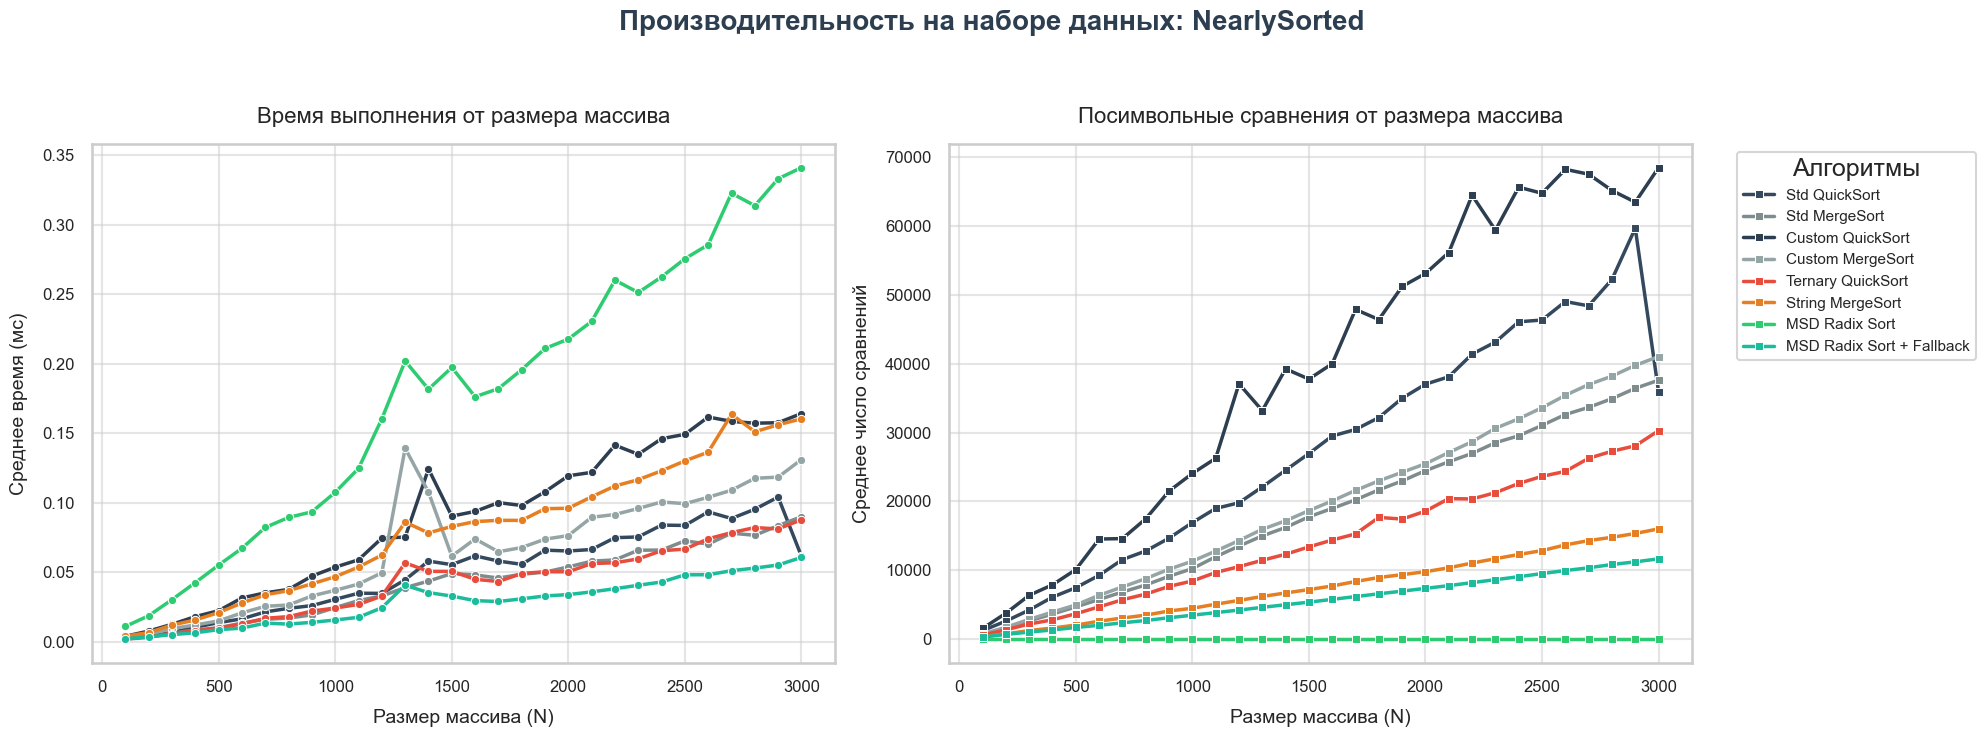

In [16]:
plot_dataset('NearlySorted')

### 4. Строки с длинным общим префиксом (Shared Prefix)
Это самый показательный стресс-тест! Все строки имеют общий префикс длиной 50 символов.

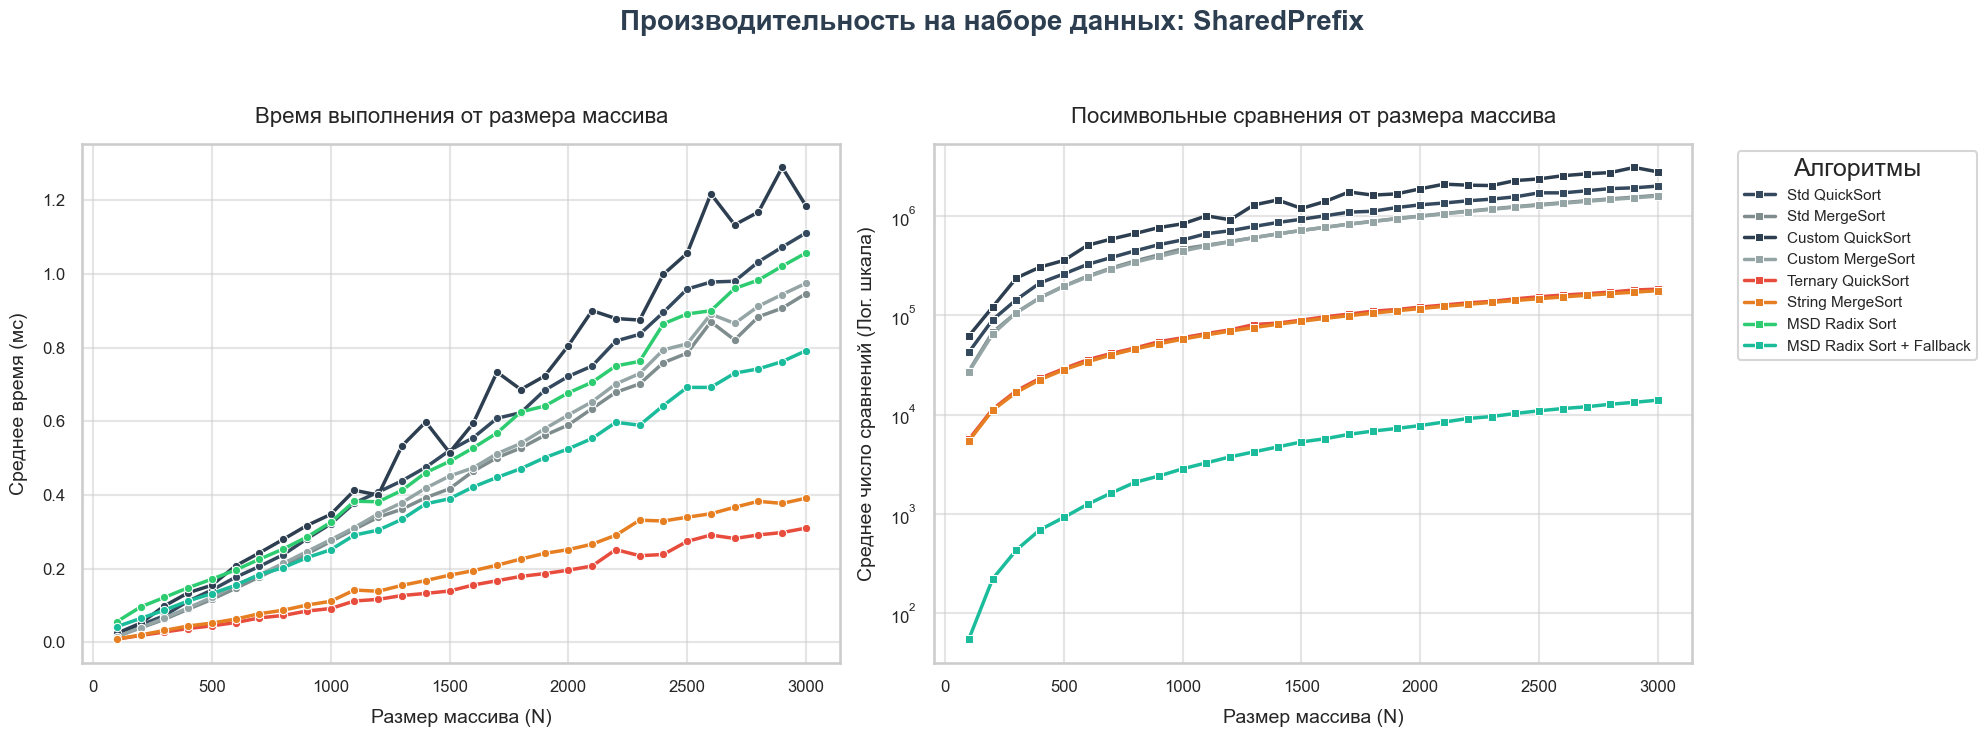

In [17]:
plot_dataset('SharedPrefix', use_log=True)

## Теоретическая Сложность vs. Практика


| Алгоритм | Худшее время | Среднее время | Память | Поведение на SharedPrefix (Практика)                               |
| :--- | :--- | :--- | :--- |:-------------------------------------------------------------------|
| **Std QuickSort** | $O(L \cdot N \log N)$ | $O(L \cdot N \log N)$ | $O(\log N)$ | Медленно. Страдает от избыточных сравнений общего префикса.        |
| **Std MergeSort** | $O(L \cdot N \log N)$ | $O(L \cdot N \log N)$ | $O(N)$ | Стабилен, но тратит много времени на дублирующиеся префиксы.       |
| **Ternary QuickSort** | $O(L \cdot N + N \log N)$ | $O(D + N \log N)$ | $O(L + \log N)$ | **Экстремально быстро**. Эффективно «проскакивает» общие префиксы. |
| **String MergeSort** | $O(D + N \log N)$ | $O(D + N \log N)$ | $O(N)$ | **Очень эффективно**. Экономит до 90% сравнений за счет LCP-кэша.  |
| **MSD Radix Sort** | $O(L \cdot N + R \cdot L)$ | $O(L \cdot N + R \cdot L)$ | $O(N + R)$ | медленно на длинных пустых префиксах (избыток корзин).             |
| **MSD + Fallback** | $O(D + N \log N)$ | $O(D + N \log N)$ | $O(N + R)$ | **Абсолютный сбалансированный лидер** на любых типах данных.       |

*(L — макс. длина строки, D — суммарная длина LCP всех строк, R — размер алфавита)*
